### 05 — Temporal Regime Analysis: Horizon-Based Predictive Decay

#### Objective

This notebook evaluates how predictive performance changes across forecast horizons (1–5 years).

We investigate:

1. Does predictive power decline as forecast horizon increases?
2. Are short-term and long-term bankruptcies structurally different?
3. Do nonlinear models retain strength across time?

---

#### Motivation

Corporate distress evolves over time.

Possible regimes:

- **Short-term (1 year):**
  Acute liquidity stress or sudden financial collapse.

- **Medium-term (2–4 years):**
  Structural uncertainty, recovery attempts, volatility.

- **Long-term (5 years):**
  Chronic structural weakness emerging over time.

If bankruptcy drivers differ by time horizon,
predictive performance and model behavior should reflect this.

---

#### Experimental Design

For each dataset (1year–5year):

- Same XGBoost configuration
- Same preprocessing pipeline
- Same evaluation metrics
- No horizon-specific tuning

This ensures performance differences reflect data regime shifts,
not modeling artifacts.

In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score

from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [2]:
def evaluate_horizon(file_path):
    data, meta = arff.loadarff(file_path)
    df = pd.DataFrame(data)

    df["class"] = df["class"].apply(lambda x: int(x.decode("utf-8")))

    X = df.drop(columns=["class"])
    y = df["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, probs)
    pr = average_precision_score(y_test, probs)

    return roc, pr

In [3]:
horizons = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]

roc_scores = []
pr_scores = []

for file in horizons:
    roc, pr = evaluate_horizon(f"../data/raw/{file}")
    roc_scores.append(roc)
    pr_scores.append(pr)

results = pd.DataFrame({
    "Horizon": [1,2,3,4,5],
    "ROC_AUC": roc_scores,
    "PR_AUC": pr_scores
})

results

,Horizon,ROC_AUC,PR_AUC
0,1,0.968592,0.821264
1,2,0.929338,0.671607
2,3,0.916392,0.625161
3,4,0.893787,0.630817
4,5,0.949191,0.742638


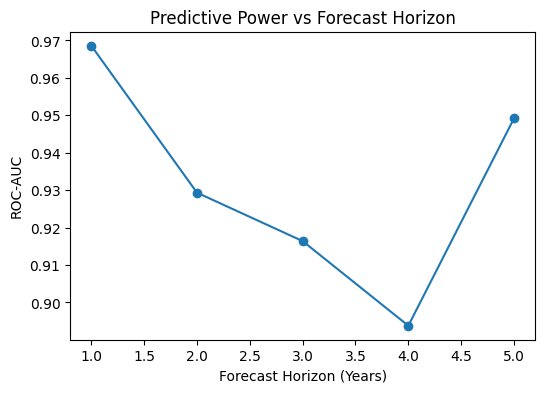

In [8]:
plt.figure(figsize=(6,4))
plt.plot(results["Horizon"], results["ROC_AUC"], marker='o')
plt.xlabel("Forecast Horizon (Years)")
plt.ylabel("ROC-AUC")
plt.title("Predictive Power vs Forecast Horizon")

plt.savefig("../results/horizon_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
from scipy.io import arff
import pandas as pd

horizons = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]

for file in horizons:
    data, meta = arff.loadarff(f"../data/raw/{file}")
    df = pd.DataFrame(data)
    
    df["class"] = df["class"].apply(lambda x: int(x.decode("utf-8")))
    
    total = len(df)
    positives = df["class"].sum()
    rate = positives / total
    
    print(f"{file}")
    print(f"  Total samples: {total}")
    print(f"  Bankrupt firms: {positives}")
    print(f"  Bankruptcy rate: {round(rate, 4)}")
    print("-" * 40)

1year.arff
  Total samples: 7027
  Bankrupt firms: 271
  Bankruptcy rate: 0.0386
----------------------------------------
2year.arff
  Total samples: 10173
  Bankrupt firms: 400
  Bankruptcy rate: 0.0393
----------------------------------------
3year.arff
  Total samples: 10503
  Bankrupt firms: 495
  Bankruptcy rate: 0.0471
----------------------------------------
4year.arff
  Total samples: 9792
  Bankrupt firms: 515
  Bankruptcy rate: 0.0526
----------------------------------------
5year.arff
  Total samples: 5910
  Bankrupt firms: 410
  Bankruptcy rate: 0.0694
----------------------------------------


### 📌 Observations & Temporal Insights

#### 1️⃣ Performance Across Horizons

| Horizon | ROC-AUC | PR-AUC |
|----------|---------|---------|
| 1-Year | ~0.968 | ~0.821 |
| 2-Year | ~0.929 | ~0.672 |
| 3-Year | ~0.916 | ~0.625 |
| 4-Year | ~0.893 | ~0.631 |
| 5-Year | ~0.949 | ~0.743 |

---

#### 2️⃣ Medium-Term Predictive Decay

Performance declines from 1 → 4 years.

This suggests:

- Medium-term bankruptcy is structurally noisier.
- Firms may recover or deteriorate unpredictably.
- Financial fragility becomes less sharply separable.

---

#### 3️⃣ 5-Year Partial Recovery

Performance improves again at 5-year.

Possible explanation:

- Long-horizon failures represent chronic structural weakness.
- Deep fragility becomes more distinguishable from healthy firms.

---

#### 4️⃣ Bankruptcy Prevalence Increases

Bankruptcy rate increases from:

- ~3.86% (1-year)
- → ~6.94% (5-year)

Higher prevalence alters class structure and separability.

---

#### 5️⃣ Structural Takeaway

Bankruptcy risk is not temporally uniform.

We observe:

- Acute distress (short-term)
- Uncertain transitional regime (medium-term)
- Chronic fragility (long-term)

Temporal regime analysis reveals deeper financial system dynamics beyond static prediction.